In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../data/processed/caries_features.parquet")

In [20]:
# X = df.drop(columns=["has_caries"])
# y = df["has_caries"]
X = df[
    [
        "n_missing_teeth",
        "n_filled_teeth"
    ]
]

y = (df["has_root_caries"] == 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=101)

In [21]:
model = LogisticRegression(max_iter=1000,solver="lbfgs")

In [22]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
carries_predictions = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [32]:
threshold = 0.15
y_pred_tuned = (y_prob >= threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))


[[3649  158]
 [ 324    1]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3807
           1       0.01      0.00      0.00       325

    accuracy                           0.88      4132
   macro avg       0.46      0.48      0.47      4132
weighted avg       0.85      0.88      0.86      4132



In [25]:
roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

0.6099258451031501

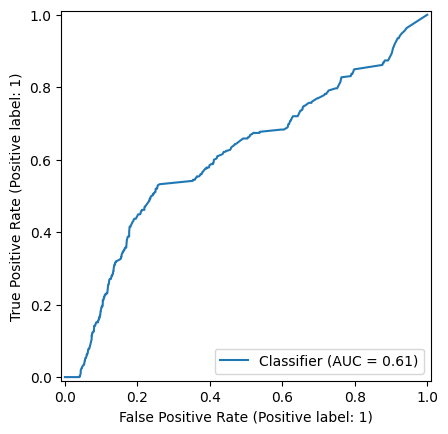

In [26]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()


In [27]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
0,n_missing_teeth,0.038801
1,n_filled_teeth,0.023920


In [30]:
import numpy as np

In [31]:
np.percentile(y_prob, [50, 75, 90, 95, 99])

array([0.07235666, 0.0834907 , 0.1096899 , 0.13940523, 0.15994683])

In [ ]:
a=